In [1]:
#Libraries
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import convolve, Gaussian2DKernel, Tophat2DKernel
import os
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.nddata import Cutout2D

from astropy.modeling.models import Gaussian2D
from reproject import reproject_interp
import matplotlib.pyplot as plt
#exception handeling
import warnings
warnings.simplefilter('ignore')

In [2]:
def generate_source(input_resolution, pixel_scale, grid_size=301):
    #generate sigma
    input_sigma = input_resolution / 2.355

    #generate pixel scale
    input_sigma_pix = input_sigma / pixel_scale

    #set grid size
    ny = nx = grid_size
    y, x = np.indices((ny, nx))
    cy, cx = nx // 2 , ny // 2 #set centerpoint floored

    #generate gaussian source
    gaussian_source = np.exp(-((x-cx)**2 + (y-cy)**2) / (2 * input_sigma_pix**2))

    return gaussian_source

def create_test_source_fits(ref_fits, save_path, resolution=1.2, grid_size=100):
    #load wcs information from reference fits
    hdu_ref = fits.open(ref_fits)
    wcs = WCS(hdu_ref[0].header)

    #grab pixel scale from reference fits
    pixel_scale = wcs.proj_plane_pixel_scales()[0].to_value(u.deg) * 3600.0  # arcsec/pixel

    #generate source
    source = generate_source(resolution, pixel_scale)

    #save test source fits
    hdu = fits.PrimaryHDU(source, header=hdu_ref[0].header)
    
    # (optional) remove data WCS keywords beyond basic proj
    for key in list(hdu.header.keys()):
        if key.startswith("PC") or key.startswith("CD") or key.startswith("CDELT") or key.startswith("CRPIX") or key.startswith("CRVAL"):
            continue
    # keep only minimal necessary WCS to avoid reprojection confusion
    hdu.writeto(save_path, overwrite=True)

# def convolve():
#     target_sigma = target_resolution / 2.355

#     #initialize sigma kernal
#     sigma_kernal = np.sqrt(target_sigma**2 - input_sigma**2)

#     sigma_kernel_pix = sigma_kernel / pixel_scale

In [3]:
#generate gaussian source

#source parameters
resolution = 1.2 #fwhm
pixel_scale = 8.4722204e-05 * 3600 #ha (arcsec/pixel)

test_source = generate_source(resolution, pixel_scale)

# plt.plot(test_source)

In [4]:
#test fits source maker

reference_path = "../../Data/STARTAstro_dwarf_shells/test-data/WLM_test_ha.fits"
save_path = "./test.fits"

create_test_source_fits(reference_path, save_path)

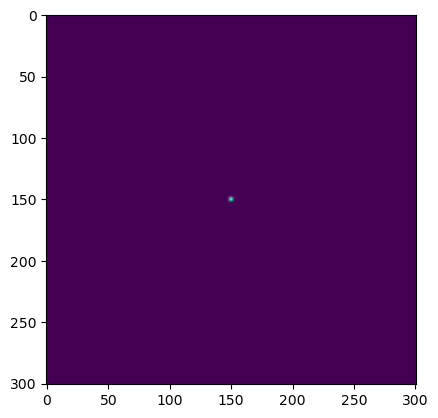

In [5]:
hdu = fits.open(save_path)

plt.imshow(hdu[0].data)

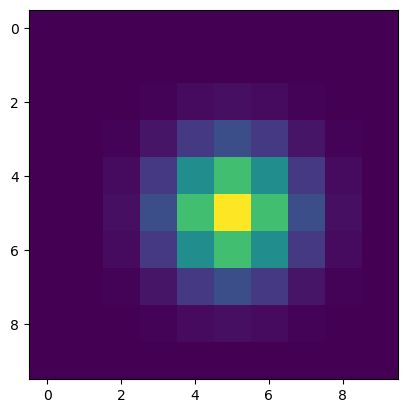

In [6]:
#cut around source
#cut image
cutout_obj = Cutout2D(data=hdu[0].data, position=(150,150), size=2*5)
plt.imshow(cutout_obj.data)

In [7]:
def reproject_image(target_fits, object_fits, target_arcsec_per_pix, oblect_arcsec_per_pix, target_fwhm = 6, object_fwhm = 1.2):

    #initialize target header
    target_header = target_fits[0].header

    #initialize target wcs
    target_wcs = WCS(target_header)

    #initialize object header
    object_header = object_fits[0].header

    #initialize object wcs
    object_wcs = WCS(object_header)

    #iterate wcs
    for index in range(0, target_wcs.naxis if target_wcs.naxis >= object_wcs.naxis else object_wcs.naxis):
        #print(target_wcs.naxis, object_wcs.naxis)

        #check wcs size
        if target_wcs.naxis > object_wcs.naxis:

            #reduce wcs size
            target_wcs = target_wcs.dropaxis(2)

        #check wcs size
        elif object_wcs.naxis > target_wcs.naxis:

            #reduce wcs size
            object_wcs = object_wcs.dropaxis(2)
        else:
            continue

    #print(target_wcs.naxis)
    
    #reproject object with target parameters
    object_reprojected, footprint = reproject_interp(object_fits, target_wcs)

    #calculate sigmas
    object_sig = object_fwhm/(2* (np.sqrt(2*np.log(2))))/target_arcsec_per_pix
    target_sig = target_fwhm/(2* (np.sqrt(2*np.log(2))))/target_arcsec_per_pix

    #generate kernal
    ker = np.sqrt((target_sig**2)-(object_sig**2))
    
    #calculate gaussian
    gauss_kernel = Gaussian2DKernel(ker)

    #smooth object image
    smoothed_data_gauss = convolve(object_reprojected, gauss_kernel)

    return smoothed_data_gauss

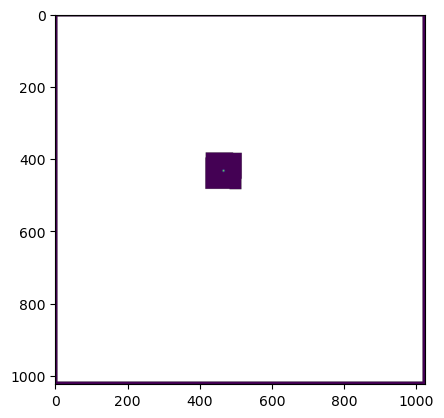

In [8]:
target_fits = fits.open("../../Data/STARTAstro_dwarf_shells/test-data/WLM_test_hi.FITS")

#arc pix hi
test_target_arc_per_pix = 4.166666768E-04 * 3600

convolve_test = reproject_image(target_fits, hdu, test_target_arc_per_pix, pixel_scale)
plt.imshow(convolve_test)

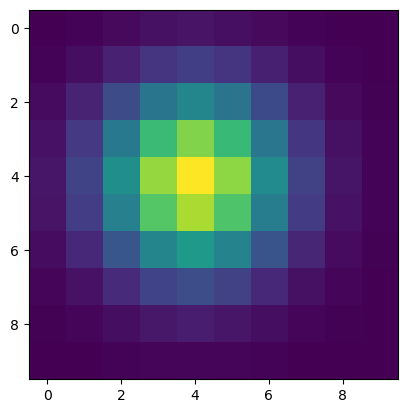

In [9]:
cutout = Cutout2D(convolve_test, position=(467,434), size=2*5)
plt.imshow(cutout.data)

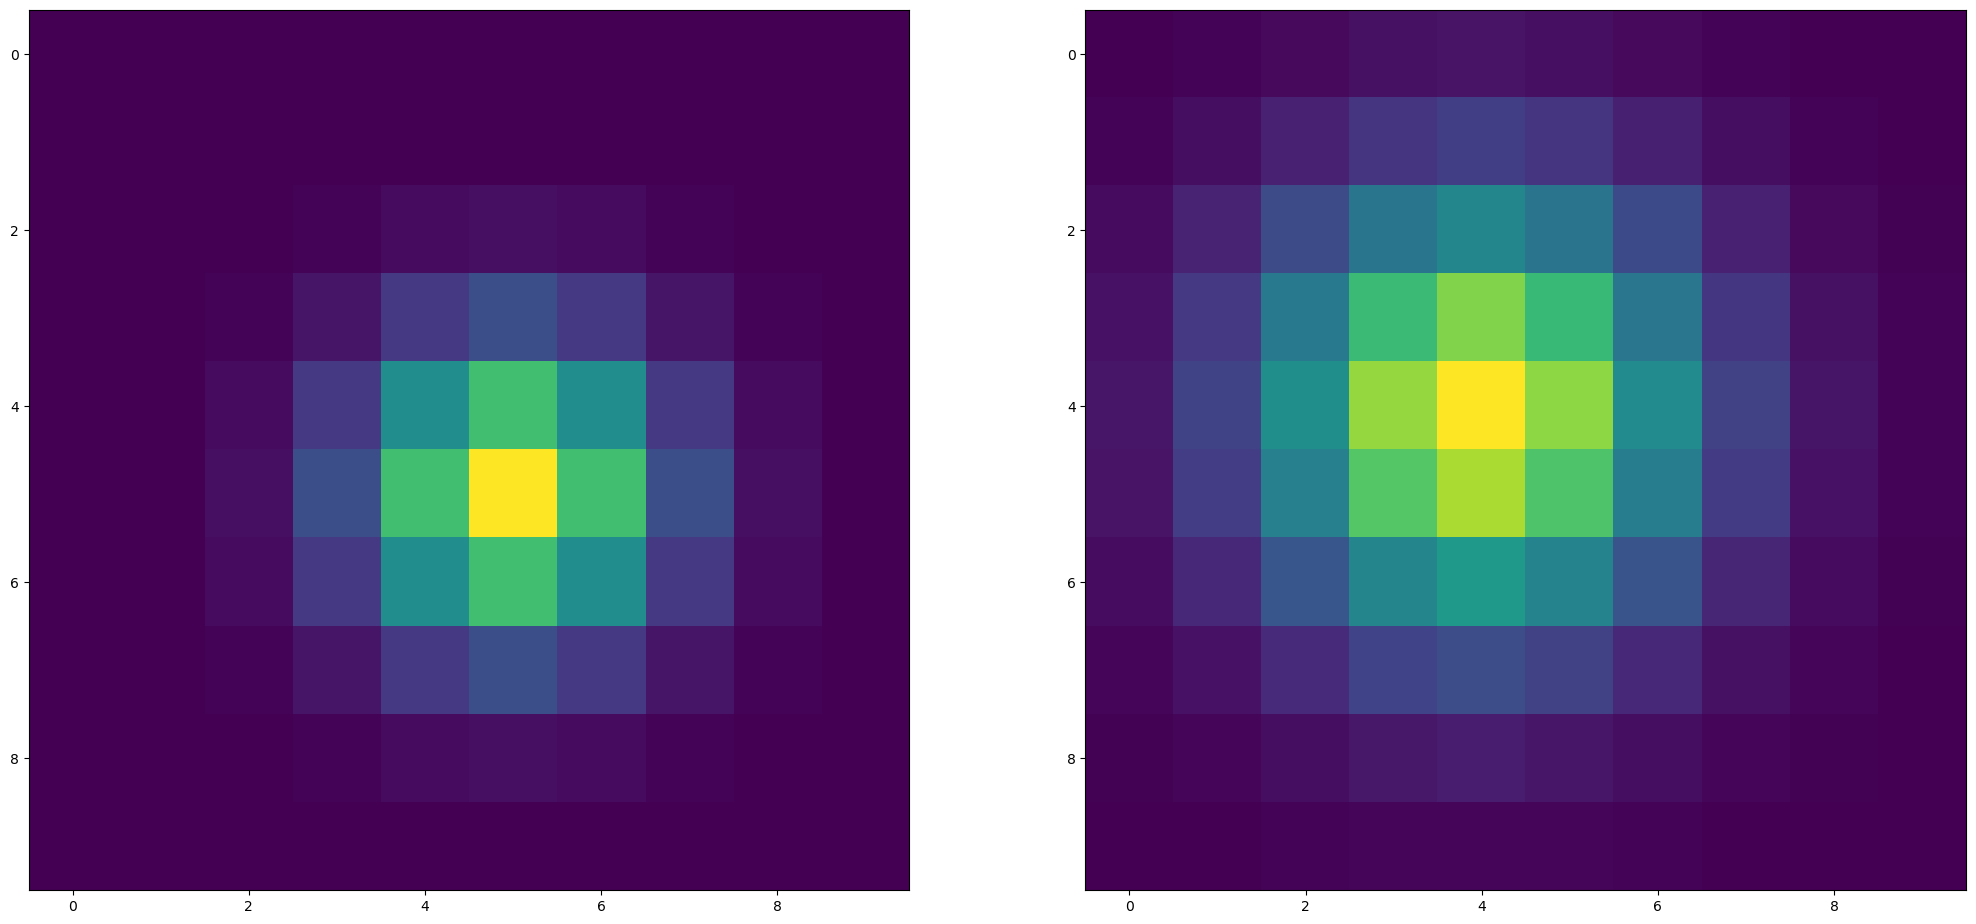

In [10]:
plt.figure(figsize=(25,35))

plt.subplot(121)
plt.imshow(cutout_obj.data)

plt.subplot(122)
plt.imshow(cutout.data)